# HW10-11: CNN, Transfer Learning и Segmentation

В этой работе выполнены обе обязательные части:
- часть A: классификация изображений на `CIFAR100` с экспериментами `C1-C4`;
- часть B: segmentation track на `OxfordIIITPet` с режимами `V1-V2`.


## 1. Импорты, seed, устройство и папки для артефактов


In [7]:
import csv
import json
import random
from collections import defaultdict
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights, deeplabv3_resnet50
from torchvision.utils import draw_segmentation_masks, make_grid

%matplotlib inline
plt.style.use("ggplot")

ROOT = Path(".")
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_workers = 2 if device.type == "cuda" else 0

print(f"Device: {device}")
print(f"Seed: {SEED}")
print(f"Artifacts: {ARTIFACTS_DIR.resolve()}")


Device: cpu
Seed: 42
Artifacts: C:\Users\vt240\OneDrive\Рабочий стол\prog\II-cafedra\aie-student-template\homeworks\HW10-11\artifacts


## 2. Конфигурация экспериментов


In [8]:
CLASSIFICATION_DATASET = "CIFAR100"
VAL_RATIO = 0.2
BATCH_SIZE_CNN = 128
BATCH_SIZE_RESNET = 64
CNN_EPOCHS = 8
RESNET_HEAD_EPOCHS = 5
RESNET_FINETUNE_EPOCHS = 5
LEARNING_RATE_CNN = 1e-3
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINETUNE = 3e-4
WEIGHT_DECAY = 1e-4

SEGMENTATION_DATASET = "OxfordIIITPet"
SEG_BATCH_SIZE = 4
SEG_MAX_SAMPLES = 24
SEG_V1_THRESHOLD = 0.5
SEG_V2_THRESHOLD = 0.6
SEG_MIN_COMPONENT_AREA = 120

print("Classification dataset:", CLASSIFICATION_DATASET)
print("Segmentation dataset:", SEGMENTATION_DATASET)


Classification dataset: CIFAR100
Segmentation dataset: OxfordIIITPet


## 3. Данные части A: классификация на CIFAR100


In [9]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, target = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, target

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
])

aug_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
])

resnet_weights = ResNet18_Weights.DEFAULT
resnet_transform = resnet_weights.transforms()

cifar_train_raw = datasets.CIFAR100(root=DATA_DIR, train=True, download=True)
cifar_test_raw = datasets.CIFAR100(root=DATA_DIR, train=False, download=True)
cifar_classes = cifar_train_raw.classes

dataset_size = len(cifar_train_raw)
val_size = int(dataset_size * VAL_RATIO)
train_size = dataset_size - val_size
split_generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(dataset_size, generator=split_generator).tolist()
train_indices = permutation[:train_size]
val_indices = permutation[train_size:]

train_dataset_cnn_base = TransformSubset(cifar_train_raw, train_indices, transform=base_transform)
train_dataset_cnn_aug = TransformSubset(cifar_train_raw, train_indices, transform=aug_transform)
val_dataset_cnn = TransformSubset(cifar_train_raw, val_indices, transform=base_transform)
test_dataset_cnn = TransformSubset(cifar_test_raw, range(len(cifar_test_raw)), transform=base_transform)

train_dataset_resnet = TransformSubset(cifar_train_raw, train_indices, transform=resnet_transform)
val_dataset_resnet = TransformSubset(cifar_train_raw, val_indices, transform=resnet_transform)
test_dataset_resnet = TransformSubset(cifar_test_raw, range(len(cifar_test_raw)), transform=resnet_transform)

loaders = {
    "cnn_base": {
        "train": DataLoader(train_dataset_cnn_base, batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=num_workers),
        "val": DataLoader(val_dataset_cnn, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=num_workers),
        "test": DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=num_workers),
    },
    "cnn_aug": {
        "train": DataLoader(train_dataset_cnn_aug, batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=num_workers),
        "val": DataLoader(val_dataset_cnn, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=num_workers),
        "test": DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=num_workers),
    },
    "resnet": {
        "train": DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=True, num_workers=num_workers),
        "val": DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=False, num_workers=num_workers),
        "test": DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=False, num_workers=num_workers),
    },
}

print(f"Train size: {len(train_indices)}")
print(f"Val size: {len(val_indices)}")
print(f"Test size: {len(cifar_test_raw)}")


Train size: 40000
Val size: 10000
Test size: 10000


Part A sanity-check
x.shape: (128, 3, 32, 32)
y.shape: (128,)
batch min/max: -1.8974658250808716 2.025352954864502


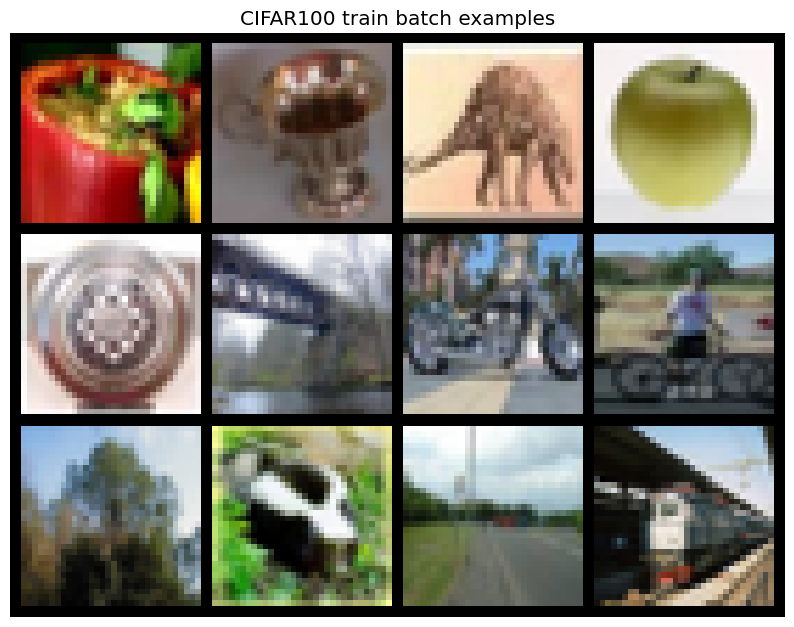

In [10]:
def denormalize_batch(batch, mean, std):
    mean = torch.tensor(mean).view(1, -1, 1, 1)
    std = torch.tensor(std).view(1, -1, 1, 1)
    return (batch.cpu() * std) + mean

sample_images, sample_labels = next(iter(loaders["cnn_base"]["train"]))
print("Part A sanity-check")
print("x.shape:", tuple(sample_images.shape))
print("y.shape:", tuple(sample_labels.shape))
print("batch min/max:", float(sample_images.min()), float(sample_images.max()))

preview = denormalize_batch(sample_images[:12], mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]).clamp(0, 1)
grid = make_grid(preview, nrow=4)
plt.figure(figsize=(10, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("CIFAR100 train batch examples")
plt.show()


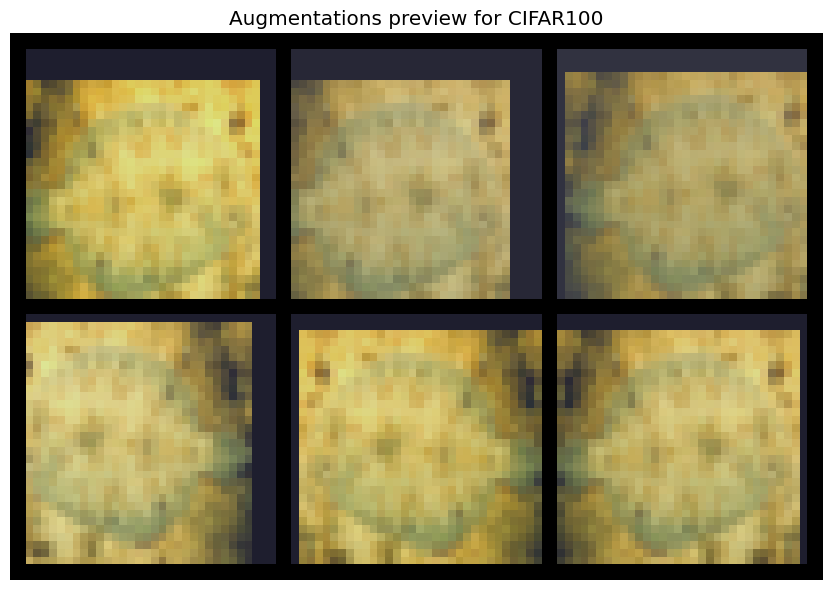

In [11]:
aug_preview_images = []
pil_image, _ = cifar_train_raw[train_indices[0]]
for _ in range(6):
    aug_preview_images.append(aug_transform(pil_image))

aug_grid = make_grid(torch.stack(aug_preview_images), nrow=3, normalize=True, value_range=(-2.5, 2.5))
plt.figure(figsize=(9, 6))
plt.imshow(aug_grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Augmentations preview for CIFAR100")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Данные части B: segmentation на OxfordIIITPet


In [13]:
seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_image_transform = seg_weights.transforms()
SEG_IMAGE_SIZE = (384, 384)
seg_resize_image = transforms.Resize(SEG_IMAGE_SIZE, interpolation=transforms.InterpolationMode.BILINEAR)
seg_resize_mask = transforms.Resize(SEG_IMAGE_SIZE, interpolation=transforms.InterpolationMode.NEAREST)
voc_categories = seg_weights.meta["categories"]
CAT_CLASS_IDX = voc_categories.index("cat")
DOG_CLASS_IDX = voc_categories.index("dog")

class OxfordPetSegmentationDataset(Dataset):
    def __init__(self, root, split, max_samples=None):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=True,
        )
        self.indices = list(range(len(self.dataset)))
        if max_samples is not None:
            self.indices = self.indices[:max_samples]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, target = self.dataset[real_idx]
        category, trimap = target

        resized_image = seg_resize_image(image)
        resized_trimap = seg_resize_mask(trimap)
        image_tensor = seg_image_transform(resized_image)

        trimap_np = np.array(resized_trimap, dtype=np.int64)
        foreground_mask = np.isin(trimap_np, [1, 3]).astype(np.uint8)

        original_image = transforms.ToTensor()(resized_image)
        return {
            "image": image_tensor,
            "gt_mask": torch.from_numpy(foreground_mask),
            "original_image": original_image,
            "category": int(category),
        }

def ensure_image_size(image_tensor, size=SEG_IMAGE_SIZE):
    if tuple(image_tensor.shape[-2:]) == size:
        return image_tensor
    resized = F.interpolate(
        image_tensor.unsqueeze(0),
        size=size,
        mode="bilinear",
        align_corners=False,
    )
    return resized.squeeze(0)

def ensure_mask_size(mask_tensor, size=SEG_IMAGE_SIZE):
    if tuple(mask_tensor.shape[-2:]) == size:
        return mask_tensor
    resized = F.interpolate(
        mask_tensor.unsqueeze(0).unsqueeze(0).float(),
        size=size,
        mode="nearest",
    )
    return resized.squeeze(0).squeeze(0).to(mask_tensor.dtype)

def seg_collate_fn(batch):
    images = torch.stack([ensure_image_size(item["image"]) for item in batch])
    gt_masks = torch.stack([ensure_mask_size(item["gt_mask"]) for item in batch])
    original_images = torch.stack([ensure_image_size(item["original_image"]) for item in batch])
    categories = torch.tensor([item["category"] for item in batch], dtype=torch.long)
    return {
        "image": images,
        "gt_mask": gt_masks,
        "original_image": original_images,
        "category": categories,
    }

pet_seg_dataset = OxfordPetSegmentationDataset(DATA_DIR, split="test", max_samples=SEG_MAX_SAMPLES)
pet_seg_loader = DataLoader(
    pet_seg_dataset,
    batch_size=SEG_BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=seg_collate_fn,
)

seg_batch = next(iter(pet_seg_loader))
print("Part B sanity-check")
print("image.shape:", tuple(seg_batch["image"].shape))
print("gt_mask.shape:", tuple(seg_batch["gt_mask"].shape))
print("categories:", seg_batch["category"].tolist())


Part B sanity-check
image.shape: (4, 3, 384, 384)
gt_mask.shape: (4, 384, 384)
categories: [0, 0, 0, 0]


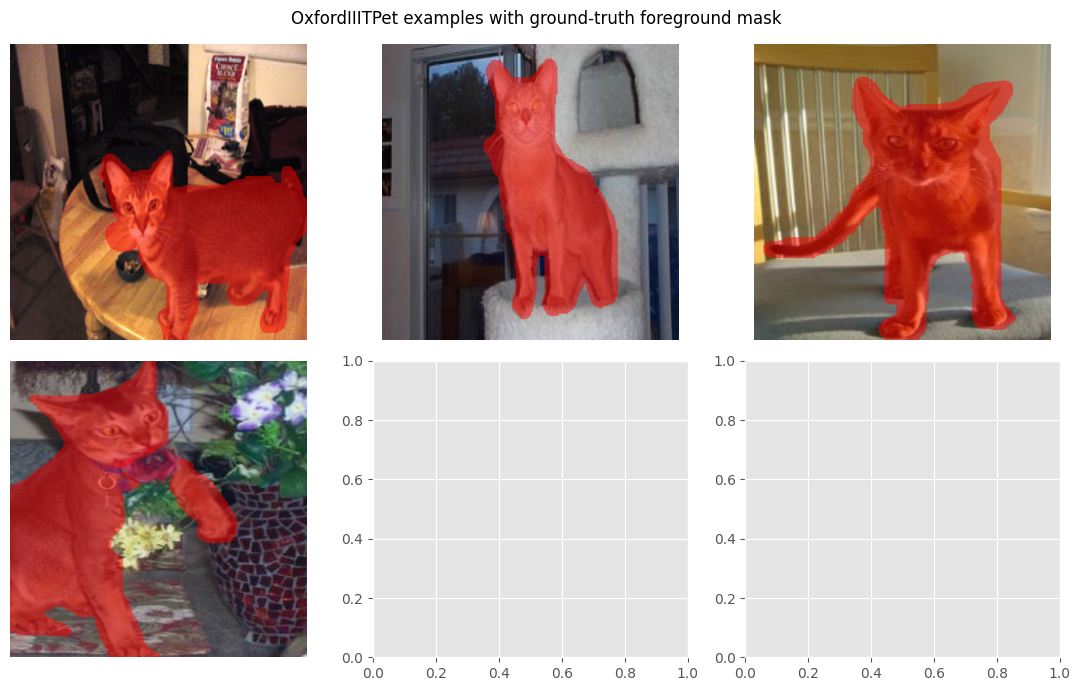

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, img, mask in zip(axes.flatten(), seg_batch["original_image"][:6], seg_batch["gt_mask"][:6]):
    overlay = draw_segmentation_masks((img * 255).to(torch.uint8), masks=mask.bool(), alpha=0.5, colors="red")
    ax.imshow(overlay.permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("OxfordIIITPet examples with ground-truth foreground mask")
plt.tight_layout()
plt.show()


## 5. Модели, train/eval цикл и общие функции


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.1),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_resnet18_head_only(num_classes=100):
    model = resnet18(weights=resnet_weights)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet18_partial_finetune(num_classes=100):
    model = resnet18(weights=resnet_weights)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    for param in model.fc.parameters():
        param.requires_grad = True
    return model

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, running_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, running_correct / total


In [16]:
def run_classification_experiment(experiment_id, model, train_loader, val_loader, epochs, lr, notes):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)
    model = model.to(device)
    history = defaultdict(list)
    best_state = None
    best_val_accuracy = -1.0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        print(f"{experiment_id} | epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    result = {
        "experiment_id": experiment_id,
        "task": "classification",
        "dataset": CLASSIFICATION_DATASET,
        "seed": SEED,
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": notes,
    }
    return model, dict(history), result

@torch.no_grad()
def predict_segmentation_probabilities(model, images):
    logits = model(images)["out"]
    probs = torch.softmax(logits, dim=1)
    return torch.maximum(probs[:, CAT_CLASS_IDX], probs[:, DOG_CLASS_IDX])

def binary_open_close(mask_tensor):
    x = mask_tensor.float().unsqueeze(0).unsqueeze(0)
    eroded = 1.0 - F.max_pool2d(1.0 - x, kernel_size=3, stride=1, padding=1)
    opened = F.max_pool2d(eroded, kernel_size=3, stride=1, padding=1)
    dilated = F.max_pool2d(opened, kernel_size=3, stride=1, padding=1)
    closed = 1.0 - F.max_pool2d(1.0 - dilated, kernel_size=3, stride=1, padding=1)
    return (closed.squeeze() > 0.5)

def remove_small_components(mask_np, min_area):
    h, w = mask_np.shape
    visited = np.zeros_like(mask_np, dtype=bool)
    result = mask_np.copy()
    for y in range(h):
        for x in range(w):
            if not result[y, x] or visited[y, x]:
                continue
            stack = [(y, x)]
            coords = []
            visited[y, x] = True
            while stack:
                cy, cx = stack.pop()
                coords.append((cy, cx))
                for ny, nx in ((cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)):
                    if 0 <= ny < h and 0 <= nx < w and result[ny, nx] and not visited[ny, nx]:
                        visited[ny, nx] = True
                        stack.append((ny, nx))
            if len(coords) < min_area:
                for cy, cx in coords:
                    result[cy, cx] = False
    return result

def postprocess_mask(prob_map, mode):
    if mode == "V1":
        return prob_map >= SEG_V1_THRESHOLD
    if mode == "V2":
        raw_mask = prob_map >= SEG_V2_THRESHOLD
        cleaned = binary_open_close(raw_mask)
        cleaned_np = remove_small_components(cleaned.cpu().numpy().astype(bool), SEG_MIN_COMPONENT_AREA)
        return torch.from_numpy(cleaned_np)
    raise ValueError(f"Unknown mode: {mode}")

def segmentation_metrics(pred_mask, gt_mask):
    pred_mask = pred_mask.bool()
    gt_mask = gt_mask.bool()
    intersection = (pred_mask & gt_mask).sum().item()
    union = (pred_mask | gt_mask).sum().item()
    pred_sum = pred_mask.sum().item()
    gt_sum = gt_mask.sum().item()
    iou = intersection / union if union > 0 else 1.0
    precision = intersection / pred_sum if pred_sum > 0 else 0.0
    recall = intersection / gt_sum if gt_sum > 0 else 0.0
    return iou, precision, recall


## 6. Эксперименты части A: C1-C4


In [18]:
classification_histories = {}
classification_results = []
trained_models = {}

model_c1, history_c1, result_c1 = run_classification_experiment("C1", SimpleCNN(num_classes=100), loaders["cnn_base"]["train"], loaders["cnn_base"]["val"], CNN_EPOCHS, LEARNING_RATE_CNN, "simple-cnn-base; no augmentations")
trained_models["C1"] = model_c1
classification_histories["C1"] = history_c1
classification_results.append(result_c1)

model_c2, history_c2, result_c2 = run_classification_experiment("C2", SimpleCNN(num_classes=100), loaders["cnn_aug"]["train"], loaders["cnn_aug"]["val"], CNN_EPOCHS, LEARNING_RATE_CNN, "simple-cnn-aug; crop+flip+color jitter")
trained_models["C2"] = model_c2
classification_histories["C2"] = history_c2
classification_results.append(result_c2)

model_c3, history_c3, result_c3 = run_classification_experiment("C3", build_resnet18_head_only(num_classes=100), loaders["resnet"]["train"], loaders["resnet"]["val"], RESNET_HEAD_EPOCHS, LEARNING_RATE_HEAD, "resnet18-head-only; pretrained backbone frozen")
trained_models["C3"] = model_c3
classification_histories["C3"] = history_c3
classification_results.append(result_c3)

model_c4, history_c4, result_c4 = run_classification_experiment("C4", build_resnet18_partial_finetune(num_classes=100), loaders["resnet"]["train"], loaders["resnet"]["val"], RESNET_FINETUNE_EPOCHS, LEARNING_RATE_FINETUNE, "resnet18-finetune; layer4+fc trainable")
trained_models["C4"] = model_c4
classification_histories["C4"] = history_c4
classification_results.append(result_c4)
 
classification_results


C1 | epoch 01/8 | train_loss=4.0037 | train_acc=0.0824 | val_loss=3.4976 | val_acc=0.1627
C1 | epoch 02/8 | train_loss=3.4234 | train_acc=0.1663 | val_loss=3.0875 | val_acc=0.2336
C1 | epoch 03/8 | train_loss=3.1106 | train_acc=0.2179 | val_loss=2.8153 | val_acc=0.2906
C1 | epoch 04/8 | train_loss=2.8845 | train_acc=0.2596 | val_loss=2.6241 | val_acc=0.3288
C1 | epoch 05/8 | train_loss=2.7262 | train_acc=0.2885 | val_loss=2.5765 | val_acc=0.3359
C1 | epoch 06/8 | train_loss=2.6101 | train_acc=0.3115 | val_loss=2.3770 | val_acc=0.3743
C1 | epoch 07/8 | train_loss=2.5103 | train_acc=0.3303 | val_loss=2.3394 | val_acc=0.3880
C1 | epoch 08/8 | train_loss=2.4303 | train_acc=0.3488 | val_loss=2.2659 | val_acc=0.4033
C2 | epoch 01/8 | train_loss=4.1911 | train_acc=0.0545 | val_loss=3.7843 | val_acc=0.1136
C2 | epoch 02/8 | train_loss=3.8203 | train_acc=0.1029 | val_loss=3.4674 | val_acc=0.1573
C2 | epoch 03/8 | train_loss=3.6016 | train_acc=0.1321 | val_loss=3.3074 | val_acc=0.1859
C2 | epoch

[{'experiment_id': 'C1',
  'task': 'classification',
  'dataset': 'CIFAR100',
  'seed': 42,
  'optimizer': 'Adam',
  'lr': 0.001,
  'epochs_trained': 8,
  'best_val_accuracy': 0.4033,
  'test_accuracy': '',
  'precision': '',
  'recall': '',
  'mean_iou': '',
  'notes': 'simple-cnn-base; no augmentations'},
 {'experiment_id': 'C2',
  'task': 'classification',
  'dataset': 'CIFAR100',
  'seed': 42,
  'optimizer': 'Adam',
  'lr': 0.001,
  'epochs_trained': 8,
  'best_val_accuracy': 0.3098,
  'test_accuracy': '',
  'precision': '',
  'recall': '',
  'mean_iou': '',
  'notes': 'simple-cnn-aug; crop+flip+color jitter'},
 {'experiment_id': 'C3',
  'task': 'classification',
  'dataset': 'CIFAR100',
  'seed': 42,
  'optimizer': 'Adam',
  'lr': 0.001,
  'epochs_trained': 5,
  'best_val_accuracy': 0.5415,
  'test_accuracy': '',
  'precision': '',
  'recall': '',
  'mean_iou': '',
  'notes': 'resnet18-head-only; pretrained backbone frozen'},
 {'experiment_id': 'C4',
  'task': 'classification',
  

In [19]:
best_classification_result = max(classification_results, key=lambda item: item["best_val_accuracy"])
best_experiment_id = best_classification_result["experiment_id"]
best_model = trained_models[best_experiment_id]
best_history = classification_histories[best_experiment_id]
criterion = nn.CrossEntropyLoss()
test_loader_key = "resnet" if best_experiment_id in {"C3", "C4"} else ("cnn_aug" if best_experiment_id == "C2" else "cnn_base")
test_loss, test_accuracy = evaluate(best_model, loaders[test_loader_key]["test"], criterion, device)
best_classification_result["test_accuracy"] = test_accuracy
print(f"Best classification experiment: {best_experiment_id}")
print(f"Best val accuracy: {best_classification_result['best_val_accuracy']:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")


Best classification experiment: C4
Best val accuracy: 0.6655
Final test accuracy: 0.6658


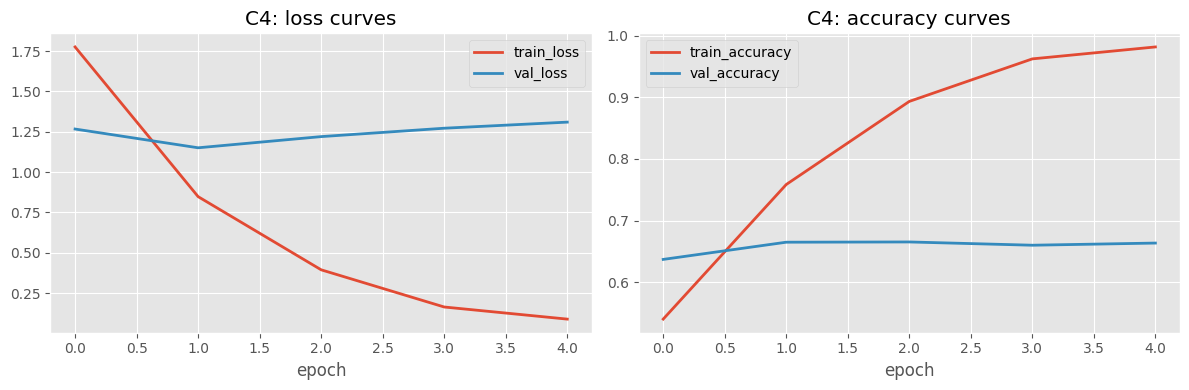

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(best_history["train_loss"], label="train_loss", linewidth=2)
axes[0].plot(best_history["val_loss"], label="val_loss", linewidth=2)
axes[0].set_title(f"{best_experiment_id}: loss curves")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(best_history["train_accuracy"], label="train_accuracy", linewidth=2)
axes[1].plot(best_history["val_accuracy"], label="val_accuracy", linewidth=2)
axes[1].set_title(f"{best_experiment_id}: accuracy curves")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()


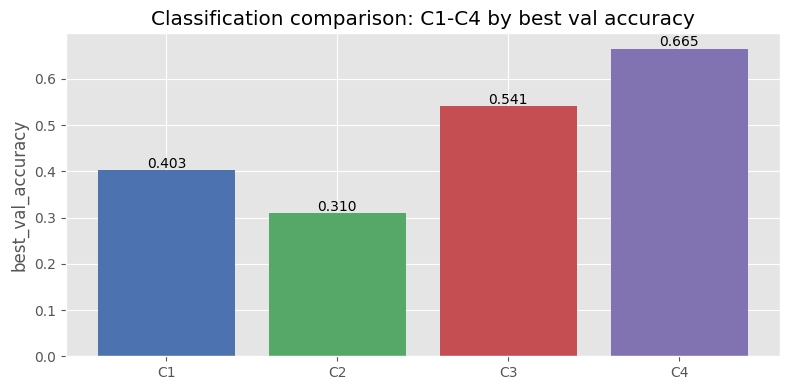

In [21]:
exp_ids = [item["experiment_id"] for item in classification_results]
val_scores = [item["best_val_accuracy"] for item in classification_results]
plt.figure(figsize=(8, 4))
bars = plt.bar(exp_ids, val_scores, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Classification comparison: C1-C4 by best val accuracy")
plt.ylabel("best_val_accuracy")
for bar, score in zip(bars, val_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.005, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Эксперименты части B: segmentation track, V1-V2


In [22]:
seg_model = deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()
segmentation_metrics_by_mode = {"V1": [], "V2": []}
segmentation_examples = []

with torch.no_grad():
    for batch in pet_seg_loader:
        images = batch["image"].to(device)
        gt_masks = batch["gt_mask"]
        original_images = batch["original_image"]
        prob_maps = predict_segmentation_probabilities(seg_model, images).cpu()
        for idx in range(images.size(0)):
            gt_mask = gt_masks[idx]
            prob_map = prob_maps[idx]
            pred_v1 = postprocess_mask(prob_map, mode="V1")
            pred_v2 = postprocess_mask(prob_map, mode="V2")
            segmentation_metrics_by_mode["V1"].append(segmentation_metrics(pred_v1, gt_mask))
            segmentation_metrics_by_mode["V2"].append(segmentation_metrics(pred_v2, gt_mask))
            if len(segmentation_examples) < 6:
                segmentation_examples.append({
                    "image": original_images[idx],
                    "gt_mask": gt_mask,
                    "pred_v1": pred_v1,
                    "pred_v2": pred_v2,
                })

def summarize_segmentation_results(metric_triplets):
    arr = np.array(metric_triplets)
    return {
        "mean_iou": float(arr[:, 0].mean()),
        "precision": float(arr[:, 1].mean()),
        "recall": float(arr[:, 2].mean()),
    }

v1_summary = summarize_segmentation_results(segmentation_metrics_by_mode["V1"])
v2_summary = summarize_segmentation_results(segmentation_metrics_by_mode["V2"])

segmentation_results = [
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": SEGMENTATION_DATASET,
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": v1_summary["precision"],
        "recall": v1_summary["recall"],
        "mean_iou": v1_summary["mean_iou"],
        "notes": f"threshold={SEG_V1_THRESHOLD}; pet foreground from cat/dog logits",
    },
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": SEGMENTATION_DATASET,
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": v2_summary["precision"],
        "recall": v2_summary["recall"],
        "mean_iou": v2_summary["mean_iou"],
        "notes": f"threshold={SEG_V2_THRESHOLD}; opening-closing + remove_small_components({SEG_MIN_COMPONENT_AREA})",
    },
]

print("V1 summary:", v1_summary)
print("V2 summary:", v2_summary)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\vt240/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


V1 summary: {'mean_iou': 0.7923579542618954, 'precision': 0.9427623400668445, 'recall': 0.8260042542894385}
V2 summary: {'mean_iou': 0.75624670158098, 'precision': 0.9521928159271159, 'recall': 0.7812229318948493}


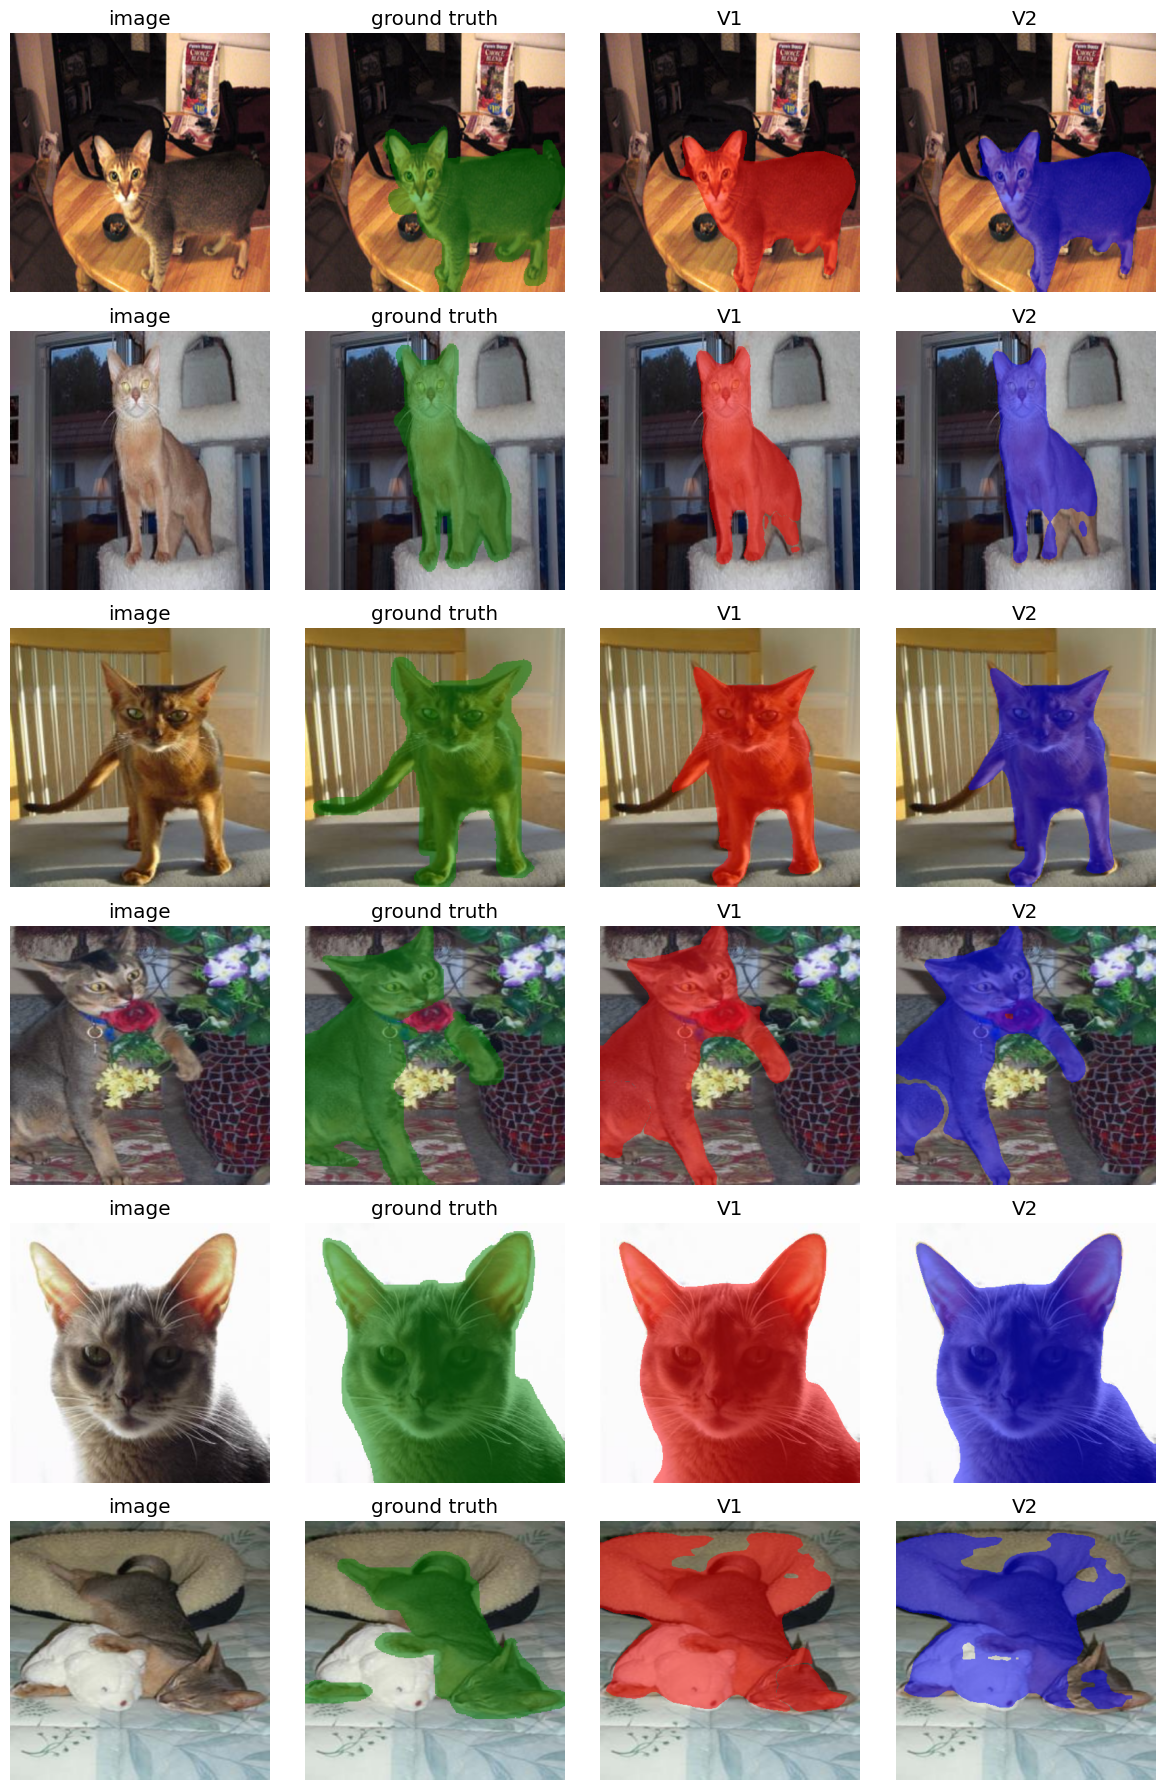

In [23]:
fig, axes = plt.subplots(len(segmentation_examples), 4, figsize=(12, 3 * len(segmentation_examples)))
for row, example in enumerate(segmentation_examples):
    img = (example["image"] * 255).to(torch.uint8)
    gt_overlay = draw_segmentation_masks(img.clone(), example["gt_mask"].bool(), alpha=0.5, colors="green")
    v1_overlay = draw_segmentation_masks(img.clone(), example["pred_v1"].bool(), alpha=0.5, colors="red")
    v2_overlay = draw_segmentation_masks(img.clone(), example["pred_v2"].bool(), alpha=0.5, colors="blue")
    axes[row, 0].imshow(img.permute(1, 2, 0))
    axes[row, 0].set_title("image")
    axes[row, 1].imshow(gt_overlay.permute(1, 2, 0))
    axes[row, 1].set_title("ground truth")
    axes[row, 2].imshow(v1_overlay.permute(1, 2, 0))
    axes[row, 2].set_title("V1")
    axes[row, 3].imshow(v2_overlay.permute(1, 2, 0))
    axes[row, 3].set_title("V2")
    for col in range(4):
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()


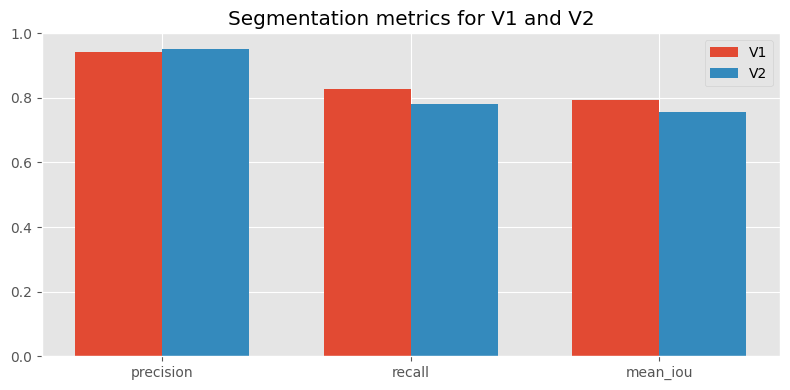

In [24]:
metric_names = ["precision", "recall", "mean_iou"]
v1_values = [v1_summary[name] for name in metric_names]
v2_values = [v2_summary[name] for name in metric_names]
x = np.arange(len(metric_names))
width = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, v1_values, width=width, label="V1")
plt.bar(x + width / 2, v2_values, width=width, label="V2")
plt.xticks(x, metric_names)
plt.ylim(0, 1)
plt.title("Segmentation metrics for V1 and V2")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Сохранение артефактов: weights, config, runs.csv


In [25]:
model_summary_map = {
    "C1": "SimpleCNN base",
    "C2": "SimpleCNN + augmentations",
    "C3": "ResNet18 pretrained, head-only",
    "C4": "ResNet18 pretrained, layer4+fc finetune",
}

for item in classification_results:
    item["model_summary"] = model_summary_map[item["experiment_id"]]

torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")

best_classifier_config = {
    "dataset": CLASSIFICATION_DATASET,
    "seed": SEED,
    "best_experiment_id": best_experiment_id,
    "model_summary": model_summary_map[best_experiment_id],
    "val_ratio": VAL_RATIO,
    "batch_size_cnn": BATCH_SIZE_CNN,
    "batch_size_resnet": BATCH_SIZE_RESNET,
    "cnn_epochs": CNN_EPOCHS,
    "resnet_head_epochs": RESNET_HEAD_EPOCHS,
    "resnet_finetune_epochs": RESNET_FINETUNE_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "base_transform": "ToTensor + Normalize(CIFAR100 stats)",
    "augmentation_transform": "RandomCrop(32,padding=4) + RandomHorizontalFlip + ColorJitter + Normalize",
    "resnet_transform": str(resnet_transform),
    "best_val_accuracy": best_classification_result["best_val_accuracy"],
    "test_accuracy": best_classification_result["test_accuracy"],
}

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_classifier_config, f, indent=2, ensure_ascii=False)

all_results = classification_results + segmentation_results
csv_fields = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

with open(ARTIFACTS_DIR / "runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=csv_fields)
    writer.writeheader()
    for row in all_results:
        writer.writerow({field: row.get(field, "") for field in csv_fields})

print("Saved:")
print("-", ARTIFACTS_DIR / "best_classifier.pt")
print("-", ARTIFACTS_DIR / "best_classifier_config.json")
print("-", ARTIFACTS_DIR / "runs.csv")


Saved:
- artifacts\best_classifier.pt
- artifacts\best_classifier_config.json
- artifacts\runs.csv
